# 01 - Geometry and Derived Quantities

This notebook explores the geometric parameters of the Archer Midnight and shows how `evtolpy` derives key parameters like wing area, aspect ratio, and tail areas from the input parameters.

In [1]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft

aircraft = Aircraft('../Archer_Midnight.json')

## Wing Geometry

The wing area is the most important derived quantity. It is set by the stall speed constraint, the aircraft must be able to fly at low speed without stalling which is especially important for coming out of the transition phase. From the lift equation at stall:

$$S_{wing} = \frac{2 \cdot m \cdot g}{\rho \cdot V_{stall}^2 \cdot C_{L,max}}$$

This means MTOW directly drives wing area: a heavier aircraft needs a larger wing. From the wing area and wingspan, other quantities follow:

- **Aspect ratio:** $AR = b^2 / S$ -- higher AR reduces induced drag but increases structural weight
- **Root chord:** derived from area, span, and taper ratio
- **Mean aerodynamic chord (MAC):** the reference chord for aerodynamic analysis

In [2]:
print(f"Wingspan:            {aircraft.wingspan_m:.2f} m")
print(f"Wing Taper Ratio:    {aircraft.wing_taper_ratio:.3f}")
print(f"Wing t/c:            {aircraft.wing_t_p_c:.4f}")
print(f"")
print(f"--- Derived ---")
print(f"Wing Area:           {aircraft.wing_area_m2:.2f} m^2")
print(f"Wing Aspect Ratio:   {aircraft.wing_aspect_ratio:.2f}")
print(f"Wing Root Chord:     {aircraft.wing_root_chord_m:.3f} m")
print(f"Wing MAC:            {aircraft.wing_mac_m:.3f} m")

Wingspan:            15.24 m
Wing Taper Ratio:    0.400
Wing t/c:            0.1500

--- Derived ---
Wing Area:           19.68 m^2
Wing Aspect Ratio:   11.80
Wing Root Chord:     1.844 m
Wing MAC:            1.370 m


## Fuselage Geometry

The fuselage is characterized by its length, width, and height. The **fineness ratio** (length / average diameter) is a key parameter for drag estimation.

A higher fineness ratio (long and slender) generally reduces pressure drag but increases skin friction drag. Hoerner's equations use this ratio to compute a form factor ($C_{D0}/C_f$), which is then combined with the Reynolds-number-based skin friction coefficient to estimate the fuselage's contribution to total drag.

In [3]:
print(f"Fuselage Length:         {aircraft.fuselage_l_m:.2f} m")
print(f"Fuselage Width:          {aircraft.fuselage_w_m:.2f} m")
print(f"Fuselage Height:         {aircraft.fuselage_h_m:.2f} m")
print(f"")
print(f"--- Derived ---")
print(f"Fineness Ratio:          {aircraft.fuselage_fineness_ratio:.2f}")
print(f"Wetted Area:             {aircraft.fuselage_wetted_area_m2:.2f} m^2")

Fuselage Length:         9.00 m
Fuselage Width:          1.60 m
Fuselage Height:         1.60 m

--- Derived ---
Fineness Ratio:          5.62
Wetted Area:             33.93 m^2


## Empennage (Tail) Geometry

Tail areas are sized using **volume coefficients**, which relate the tail size to the wing and fuselage geometry:

$$S_{HT} = \frac{V_{HT} \cdot S_{wing} \cdot MAC}{l_{HT}}$$

$$S_{VT} = \frac{V_{VT} \cdot S_{wing} \cdot b}{l_{VT}}$$

where $V_{HT}$ and $V_{VT}$ are horizontal and vertical tail volume coefficients, and $l_{HT}$, $l_{VT}$ are the moment arms from wing to tail. Typical values for eVTOL aircraft are smaller than for conventional aircraft since the tail primarily provides trim rather than stability augmentation.

For v-tail configurations the horizontal and vertical volume coefficients are calculated by projecting the v-tail onto the vertical and horizontal planes.

In [4]:
print(f"Horiz Tail Volume Coeff: {aircraft.horiz_tail_vol_coeff:.4f}")
print(f"Vert Tail Volume Coeff:  {aircraft.vert_tail_vol_coeff:.5f}")
print(f"")
print(f"--- Derived ---")
print(f"Horiz Tail Area:         {aircraft.horiz_tail_area_m2:.2f} m^2")
print(f"Vert Tail Area:          {aircraft.vert_tail_area_m2:.2f} m^2")

Horiz Tail Volume Coeff: 0.7000
Vert Tail Volume Coeff:  0.05000

--- Derived ---
Horiz Tail Area:         4.19 m^2
Vert Tail Area:          3.33 m^2


## Component Areas Comparison

The chart below shows all the aerodynamic reference areas side by side. The wing dominates, as expected.

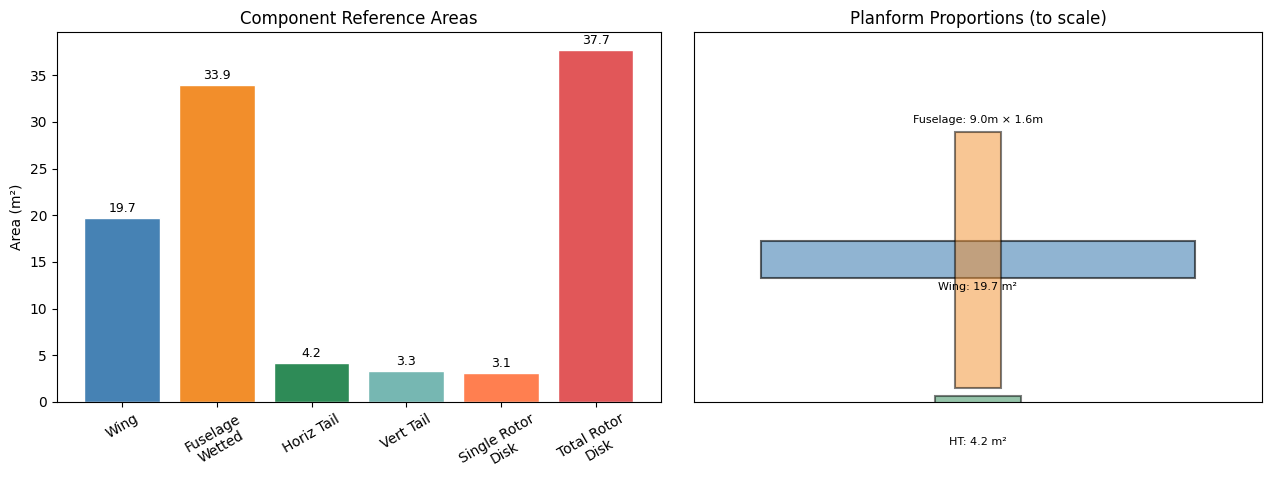

In [5]:
import matplotlib.pyplot as plt
import math

prop = aircraft.propulsion
single_disk = math.pi * (prop.rotor_diameter_m / 2.0) ** 2

area_labels = ['Wing', 'Fuselage\nWetted', 'Horiz Tail', 'Vert Tail', 'Single Rotor\nDisk', 'Total Rotor\nDisk']
area_values = [aircraft.wing_area_m2, aircraft.fuselage_wetted_area_m2,
               aircraft.horiz_tail_area_m2, aircraft.vert_tail_area_m2,
               single_disk, prop.disk_area_m2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = ['steelblue', '#f28e2b', 'seagreen', '#76b7b2', 'coral', '#e15759']
bars = axes[0].bar(area_labels, area_values, color=colors, edgecolor='white')
for bar, val in zip(bars, area_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Area (m²)')
axes[0].set_title('Component Reference Areas')
axes[0].tick_params(axis='x', rotation=30)

# Proportional rectangles (scaled top-view schematic)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-5, 8)
axes[1].set_aspect('equal')
axes[1].set_title('Planform Proportions (to scale)')

# Wing
wing_half = aircraft.wingspan_m / 2
chord = aircraft.wing_area_m2 / aircraft.wingspan_m
rect = plt.Rectangle((-wing_half, -chord/2), aircraft.wingspan_m, chord,
                      fc='steelblue', alpha=0.6, ec='black', lw=1.5)
axes[1].add_patch(rect)
axes[1].text(0, -chord/2 - 0.4, f'Wing: {aircraft.wing_area_m2:.1f} m²', ha='center', fontsize=8)

# Fuselage
fuse_rect = plt.Rectangle((-aircraft.fuselage_w_m/2, -aircraft.fuselage_l_m/2),
                            aircraft.fuselage_w_m, aircraft.fuselage_l_m,
                            fc='#f28e2b', alpha=0.5, ec='black', lw=1.5)
axes[1].add_patch(fuse_rect)
axes[1].text(0, aircraft.fuselage_l_m/2 + 0.3, f'Fuselage: {aircraft.fuselage_l_m:.1f}m × {aircraft.fuselage_w_m:.1f}m',
             ha='center', fontsize=8)

# Horiz tail
ht_span = 3.0
ht_chord = aircraft.horiz_tail_area_m2 / ht_span
ht_rect = plt.Rectangle((-ht_span/2, -aircraft.fuselage_l_m/2 - ht_chord - 0.3),
                          ht_span, ht_chord, fc='seagreen', alpha=0.5, ec='black', lw=1.5)
axes[1].add_patch(ht_rect)
axes[1].text(0, -aircraft.fuselage_l_m/2 - ht_chord - 0.6,
             f'HT: {aircraft.horiz_tail_area_m2:.1f} m²', ha='center', fontsize=8)

axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

## Summary

Key takeaways:

- **Wing area** is derived from the stall speed equation: $S = 2mg / (\rho V_{stall}^2 C_{L,max})$. It couples directly to MTOW, a heavier aircraft need bigger wings.
- **Aspect ratio** ($AR = b^2/S$) governs induced drag. The Archer Midnight's AR is typical for tilt-rotor eVTOL designs.
- **Fuselage fineness ratio** drives parasitic drag estimation via Hoerner's form factor correlation.
- **Tail areas** are sized through volume coefficients.
- The **total rotor disk area** is large compared to the wing, reflecting the need for efficient hover.

**Next:** [02 - Fixed Mass Components]